In [1]:
from google.colab import files
uploaded = files.upload()

Saving income.csv to income.csv


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv("income.csv")

print(df.head())

df = df.dropna()

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   income_level  
0             0  
1             0  
2             0  
3             0  
4             0  


In [6]:
model = AdaBoostClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy with n_estimators = 10:", accuracy)

estimators_range = range(10, 201, 10)
scores = []

for n in estimators_range:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

Accuracy with n_estimators = 10: 0.8182004299314157


Best Accuracy: 0.8334527587265841
Best n_estimators: 80


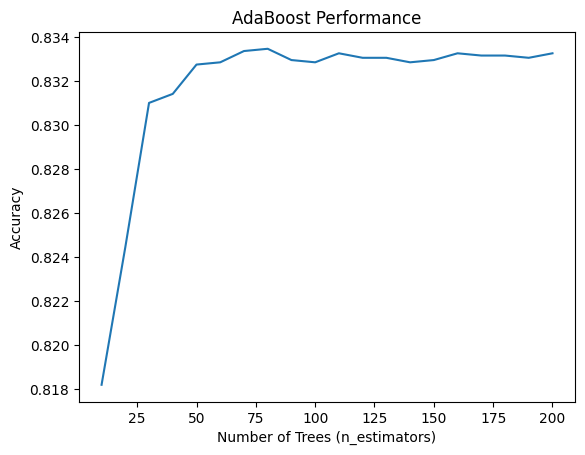

In [7]:
best_score = max(scores)
best_n = list(estimators_range)[scores.index(best_score)]

print("Best Accuracy:", best_score)
print("Best n_estimators:", best_n)

plt.plot(estimators_range, scores)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance")
plt.show()